## Notebook 8: Dynamic CBA

**New point: The feedback of AC on temperature**
- Air conditioning systems work by extracting heat from indoor spaces and rejecting it outdoors. This waste heat warms the ambient outdoor air temperature, creating a positive feedback loop: Higher outdoor T → More AC demand → More waste heat → Even higher outdoor T.
  
- This effect is disproportionately strong at night because:
    - During daytime: The deep convective boundary layer (1–3 km) disperses waste heat
      efficiently
    - During nighttime: The shallow stable boundary layer (100–300 m) traps waste heat
      near the surface

- **Implementation**:
- adds an AC waste-heat externality term to the policy scenarios: Net AC benefits = Avoided deaths from indoor cooling − Extra deaths from outdoor warming
- switchable sensitivity
    - On/off toggle via DELTA_T_CASE = "off" | "low" | "central" | "high"
    - Configurable driver: DELTA_T_DRIVER = "kwh" | "users"
- Nighttime → Daily-mean conversion (HALVING THE EFFECT):
The literature reports nighttime warming (0.5–1.0°C), but our hazard uses daily-mean T2M.
Since daily mean ≈ (Tmax + Tmin)/2 and AC waste heat only warms Tmin (night), we must halve the literature values:
    - Literature nighttime:  low=0.50°C,  central=0.75°C,  high=1.00°C
    - Applied daily-mean:    low=0.25°C,  central=0.375°C, high=0.50°C
- Incremental approach for CBA: We compute the incremental externality (policy − baseline), not absolute warming, because both scenarios have some waste-heat impact.
- Linear scaling with AC activity: We scale warming linearly with kWh consumption (or users), capped at the literature maximum.

In [31]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [32]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [33]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

- Trees policy table and citywide ΔGVI diagnostics (sum of Municipi)
- AC coverage maps + population grid
- Municipality-level coverage and kWh/user outputs from earlier notebooks
- AC efficacy by age (used on benefit side)

In [34]:
# loading everything needed for the CBA
from pathlib import Path
import json
import numpy as np
import pandas as pd

OUT = Path(OUT)
INT = Path(INT)
TAB_DIR = OUT / "tables"

# Vegetation policy / ΔGVI
trees_tbl = pd.read_csv(TAB_DIR / f"{SLUG}_trees_tbl.csv")

# diagnostics JSON with citywide ΔGVI (pop-weighted, points on 1–100 scale)
veg_diag_path = OUT / f"{SLUG}_veg_diagnostics.json"
veg_diag = json.loads(veg_diag_path.read_text())
citywide_dGVI_points_popw = veg_diag["citywide_dGVI_points_popw"]
print("Citywide pop-weighted ΔGVI (points, 1–100 scale):", citywide_dGVI_points_popw)

# AC coverage / municipal pop / energy use
# coverage maps
ac_cov_npz = np.load(INT / f"ac_coverage_maps_{SLUG}.npz")
coverage_base_3d   = ac_cov_npz["coverage_base_3d"]
coverage_policy_3d = ac_cov_npz["coverage_policy_3d"]
YEARS_AC           = ac_cov_npz["YEARS_AC"]
CITY_MASK = ac_cov_npz["CITY_MASK"].astype(bool)
HGT = int(ac_cov_npz["HGT"])
WDT = int(ac_cov_npz["WDT"])

# population on ref grid
pop_npz = np.load(INT / f"pop_on_ref_{SLUG}.npz")
pop_on_ref = pop_npz["pop"]

# municipio coverage table (pop_muni, ac_base_muni, ac_policy_muni)
muni_cov = pd.read_csv(OUT / f"muni_cov_{SLUG}.csv")

# AC consumption per municipality (kWh per AC user)
muni_tbl_all = pd.read_csv(OUT / f"{SLUG}_muni_ac_consumption_summary.csv")

# AC efficacy by age (for benefits, not directly cost-side)
eff_buckets_path = INT / f"ac_eff_buckets_{SLUG}.json"
EFF_BUCKETS = json.loads(eff_buckets_path.read_text())
EFF_BUCKETS

Citywide pop-weighted ΔGVI (points, 1–100 scale): 3.3237


{'<15': 0.3, '15-64': 0.4, '65+': 0.55}

**Discount helpers**

- Set discount rate R and horizon T
- Define PV helpers and annuity factor (PV -> equivalent annual cost)
- Convention: flows are treated as end-of-year (years 1..T)

In [35]:
import numpy as np

R = 0.03 # discount rate
T = 25 # time horizon

TREE_RAMP_YEARS = 12          # maturity ramp for both benefits and O&M
TREE_START_AGE_CENTRAL = 5    # central case (pre-grown trees)
TREE_START_AGE_SENS = 0       # sensitivity 

TREE_START_AGE_YEARS = TREE_START_AGE_CENTRAL  # the one used by the model by default

# Convention: all flows occur at END of each year => years 1..T

# present value (PV) of a constant annual flow over T years.
def pv_level_flow(annual, r=R, T=T):
    """PV of a constant annual amount paid in years 1..T."""
    yrs = np.arange(1, T+1, dtype=float)
    return float(np.sum(annual * (1 + r) ** (-yrs)))

# PV of buying an item at t=0 and then replacing it every 'life' years within the horizon.
def pv_replacements(n_items, capex_per_item, r=R, T=T, life=20):
    """ PV of buying 'n_items' at t=0 and replacing every 'life' years within horizon T. """
    pv = 0.0
    t = 0
    while t <= T:
        pv += n_items * capex_per_item / ((1+r)**t if t > 0 else 1.0)
        t += life
    return float(pv)

# annuity_factor: present value of "1 euro per year" over T years. We later use this
# to convert any PV into a constant equivalent annual cost (EAC).
def annuity_factor(r=R, T=T):
    return (1 - (1 + r) ** (-T)) / r

AF = annuity_factor(R, T)
AF

17.413147691278027

In [36]:
def pv_capex_with_ramp(new_users_t, capex_per_user, life, r=R):
    """ PV of AC capex when policy coverage ramps up over time.

    new_users_t: 1D array length T, number of new policy users in each year (vs baseline).
    capex_per_user: installation cost per AC user.
    life: years between replacements.
    r: discount rate.

    For each cohort of new users in year t, we:
    - pay capex once at installation (year t+1 in our convention)
    - then pay the same capex again every life years (replacement)
    - discount each of these payments back to year 0 and sum them up.
    """
    T = len(new_users_t)
    pv = 0.0
    for t in range(T):  # t = 0..T-1 corresponds to years 1..T
        cohort = float(new_users_t[t])
        if cohort <= 0:
            continue
        pay_year = t  # installation in year t+1, then every 'life' years
        while pay_year < T:
            pv += cohort * capex_per_user / ((1 + r) ** (pay_year + 1))
            pay_year += life
    return float(pv)

**Trees: parametrisation of costs**

- Convert ΔGVI to “index points” and apply €/index-point CAPEX
- CAPEX: linear rollout over T years
- O&M: starts the year after planting and scales with maturity (ramp years)
- start_age shifts maturity (central=5, sensitivity=0)

- Compare alternative conventions:
    - A) O&M starts immediately (old)
    - B) O&M starts next year
    - C) O&M starts next year + maturity-scaled (current best practice)

In [37]:
# Parameters from rule and regreen study
CAPEX_PER_INDEX_PT = 10_000_000.0  # eur per 1 index point (1–100 scale)

# converting per-tree CAPEX and per-tree O&M into an O&M cost per GVI point.
CAPEX_PER_TREE = 210.0    # eur per tree (REGREEN median)
OM_PER_TREE_YR = 27.0     # eur per tree per year
LIFETIME_YEARS = 25       # tree benefit/O&M lifetime

# O&M per index point per year implied by tree-level numbers
OM_PER_INDEX_PT_YR = (OM_PER_TREE_YR / CAPEX_PER_TREE) * CAPEX_PER_INDEX_PT
print("O&M per index point per year (EUR):", round(OM_PER_INDEX_PT_YR, 0))

# Total change in GVI in index point (1–100 SCALE) from trees_tbl
# trees_tbl['dGVI'] is in 0–1 (fraction of max index); sum over Municipi, then ×100 => points
DELTA_INDEX = float(trees_tbl["dGVI"].clip(lower=0).sum()) * 100.0  # sum of municipio dGVI (0–1) => index points (0–100)
print("Total ΔGVI index points (1–100 scale):", round(DELTA_INDEX, 2))

# For comparison: citywide pop-weighted ΔGVI (diagnostics)
print("Pop-weighted ΔGVI points (diagnostic):", citywide_dGVI_points_popw)

# CAPEX: linear ramp over T years
# linear rollout over 25 years
# each year we add (ΔGVI / 25) points
# pay CAPEX once for that increment in that year
# investment schedule(t) = 10M€ * (ΔGVI/25) every year, discounted year by year.
def npv_capex_linear(delta_index_total, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT):
    """
    PV of a linear ramp: we add delta_index_total/years index points each year over 'years',
    and pay capex_per_index per point.
    All flows are assumed at the end of years 1..years.
    """
    inc = delta_index_total / years  # index points added per year
    pv = 0.0
    for t in range(1, years + 1):  # t = 1..years
        capex_t = capex_per_index * inc
        pv += capex_t / ((1 + r) ** t)
    return float(pv)

# Paper-style "investment requirement" if all done at once 
TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX

PV_trees_capex = npv_capex_linear(DELTA_INDEX, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT)
print(f"Trees — Total CAPEX requirement (undiscounted): €{TREES_CAPEX_T0:,.0f}")
print(f"Trees — NPV CAPEX (linear ramp): €{PV_trees_capex:,.0f}")

# annuity factor
AF = annuity_factor(R, T)

# O&M that starts the year AFTER planting, and scales up with maturity (like benefits)
def cohort_rollout_maturity_factor_om(T, ramp_years, plant_share=None, lifetime=25, start_age_years=0):
    """
    factor[t] = sum_i plant_share[i] * maturity(age=t-i), where
      - planting year (age=0) has maturity forced to 0 => O&M starts at t+1
      - from age>=1, maturity is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    max_age = min(T, lifetime)
    ages = np.arange(max_age + 1, dtype=float)  # 0..max_age
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no O&M in planting year
    return np.convolve(plant_share, maturity)[:T]

def npv_om_cohorts_scaled(delta_index_total, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
                         ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS, start_age_years=0):
    plant_share = np.ones(years, dtype=float) / years
    factor_om = cohort_rollout_maturity_factor_om(
        T=years, ramp_years=ramp_years, plant_share=plant_share,
        lifetime=lifetime, start_age_years=start_age_years
    )
    om_stream = om_per_index_per_year * delta_index_total * factor_om
    yrs = np.arange(1, years + 1, dtype=float)
    pv = float(np.sum(om_stream * (1 + r) ** (-yrs)))
    return pv, om_stream

# calling with the new shift
PV_trees_om, om_stream_scaled = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS,
)

PV_trees_total = PV_trees_capex + PV_trees_om
EAC_capex_annuity = PV_trees_capex / AF
EAC_om_annuity = PV_trees_om / AF
EAC_total_annuity = PV_trees_total / AF

TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX
EAC_capex_paper = TREES_CAPEX_T0 / ((1 + R)**T * T)

print(f"Trees — NPV O&M (scaled with maturity): €{PV_trees_om:,.0f}")
print(f"Trees — NPV total (CAPEX + O&M): €{PV_trees_total:,.0f}")
print(f"Trees — EAC CAPEX (annuity): €{EAC_capex_annuity:,.0f}/yr")
print(f"Trees — EAC O&M (annuity): €{EAC_om_annuity:,.0f}/yr")
print(f"Trees — EAC total (annuity): €{EAC_total_annuity:,.0f}/yr")

O&M per index point per year (EUR): 1285714.0
Total ΔGVI index points (1–100 scale): 29.93
Pop-weighted ΔGVI points (diagnostic): 3.3237
Trees — Total CAPEX requirement (undiscounted): €299,328,484
Trees — NPV CAPEX (linear ramp): €208,490,044
Trees — NPV O&M (scaled with maturity): €240,655,255
Trees — NPV total (CAPEX + O&M): €449,145,299
Trees — EAC CAPEX (annuity): €11,973,139/yr
Trees — EAC O&M (annuity): €13,820,319/yr
Trees — EAC total (annuity): €25,793,458/yr


In [38]:
print("om_stream first 5:", np.round(om_stream_scaled[:5], 2))
print("om_stream last  5:", np.round(om_stream_scaled[-5:], 2))
print("om_stream max:", float(np.max(om_stream_scaled)))
print("om_stream last:", float(om_stream_scaled[-1]))

om_stream first 5: [      0.    769701.82 1667687.27 2693956.36 3848509.09]
om_stream last  5: [28094116.33 29633519.96 31172923.59 32712327.23 34251730.86]
om_stream max: 34251730.86286052
om_stream last: 34251730.86286052


In [39]:
import numpy as np
import pandas as pd

def pv_from_stream(stream, r, T):
    yrs = np.arange(1, T+1, dtype=float)
    return float(np.sum(np.asarray(stream, float) * (1 + r) ** (-yrs)))

def om_stream_constant(delta_index_total, om_per_index_per_year, T, include_planting_year: bool):
    # Constant O&M per cohort (no maturity scaling)
    inc = delta_index_total / T
    stream = np.zeros(T, dtype=float)
    for t in range(1, T+1):  # cashflows in years 1..T
        active = (t if include_planting_year else max(t-1, 0))
        stream[t-1] = active * om_per_index_per_year * inc
    return stream

def om_stream_scaled(delta_index_total, om_per_index_per_year, T, ramp_years):
    # Scaled with “maturity”, and zero in planting year by construction
    plant_share = np.ones(T, dtype=float) / T
    ages = np.arange(T+1, dtype=float)  # 0..T
    maturity = np.minimum(ages / ramp_years, 1.0)  # age 0 => 0
    factor = np.convolve(plant_share, maturity)[:T]
    return om_per_index_per_year * delta_index_total * factor

TREE_OM_RAMP_YEARS = TREE_RAMP_YEARS

# A) very old convention: O&M starts immediately
sA = om_stream_constant(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, include_planting_year=True)
PV_A = pv_from_stream(sA, R, T)

# B) point 1: O&M starts the year after planting
sB = om_stream_constant(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, include_planting_year=False)
PV_B = pv_from_stream(sB, R, T)

# C) point 2: O&M starts next year AND scales with maturity
sC = om_stream_scaled(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, ramp_years=TREE_OM_RAMP_YEARS)
PV_C = pv_from_stream(sC, R, T)

rows = []
for name, PV_om, stream in [
    ("A) O&M starts same year (old)", PV_A, sA),
    ("B) O&M starts next year", PV_B, sB),
    ("C) O&M next year + maturity-scaled", PV_C, sC),
]:
    PV_total = PV_trees_capex + PV_om
    rows.append({
        "scenario": name,
        "PV_capex": PV_trees_capex,
        "PV_om": PV_om,
        "PV_total": PV_total,
        "EAC_capex": PV_trees_capex / AF,
        "EAC_om": PV_om / AF,
        "EAC_total": PV_total / AF,
        "PV_om_over_PV_capex": PV_om / PV_trees_capex,
        "OM_year1": stream[0],
        "OM_yearT": stream[-1],
    })

compare_om = pd.DataFrame(rows)
compare_om

,scenario,PV_capex,PV_om,PV_total,EAC_capex,EAC_om,EAC_total,PV_om_over_PV_capex,OM_year1,OM_yearT
0,A) O&M starts same year (old),2.084900e+08,3.076448e+08,5.161349e+08,1.197314e+07,1.766739e+07,2.964053e+07,1.475585,1.539404e+06,3.848509e+07
1,B) O&M starts next year,2.084900e+08,2.808390e+08,4.893290e+08,1.197314e+07,1.612798e+07,2.810112e+07,1.347014,0.000000e+00,3.694569e+07
2,C) O&M next year + maturity-scaled,2.084900e+08,1.665644e+08,3.750544e+08,1.197314e+07,9.565436e+06,2.153858e+07,0.798908,0.000000e+00,2.847897e+07


- Trees O&M sensitivity: force PV(O&M) = 5 × PV(CAPEX)
   - Compute multiplier on O&M rate so the PV ratio hits the target
   - Used for “high O&M” sensitivity cases in summary tables

In [40]:
# point 3: sensitivity where PV(O&M) = 5 * PV(CAPEX) under the SAME timing convention
TARGET_OM_TO_CAPEX_PV_RATIO = 5.0  # sensitivity

# baseline under scenario C (O&M starts next year + maturity scaling)
PV_om_base, om_stream_base = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_OM_RAMP_YEARS, lifetime=LIFETIME_YEARS
)

# scale factor to hit target PV ratio
k = (TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex) / PV_om_base
OM_PER_INDEX_PT_YR_5x = OM_PER_INDEX_PT_YR * k

PV_om_5x, om_stream_5x = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR_5x,
    ramp_years=TREE_OM_RAMP_YEARS, lifetime=LIFETIME_YEARS
)

print("O&M sensitivity scaling (scenario C timing):")
print(f" PV(CAPEX) = €{PV_trees_capex:,.0f}")
print(f" Base PV(O&M) = €{PV_om_base:,.0f}")
print(f" Target PV(O&M) = €{TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex:,.0f}")
print(f" Multiplier k on OM rate = {k:.2f}x")
print(f" New PV(O&M) = €{PV_om_5x:,.0f}")

# optional: EAC comparison
print(f" Base EAC(O&M) = €{PV_om_base/AF:,.0f}/yr")
print(f" New EAC(O&M) = €{PV_om_5x/AF:,.0f}/yr")

O&M sensitivity scaling (scenario C timing):
 PV(CAPEX) = €208,490,044
 Base PV(O&M) = €166,564,355
 Target PV(O&M) = €1,042,450,222
 Multiplier k on OM rate = 6.26x
 New PV(O&M) = €1,042,450,222
 Base EAC(O&M) = €9,565,436/yr
 New EAC(O&M) = €59,865,697/yr


**Cost AC**

- AC cost model (dynamic coverage + dynamic kWh/user)
  - Coverage ramps by municipality over time (policy - baseline)
  - New users cohorts drive CAPEX and replacement cycles
  - Ongoing costs: maintenance + electricity (kWh/user interpolated over horizon)

In [41]:
# Dynamic AC horizon years (aligned with NB7 / CLIMADA outputs)
# We only need the start year and the list of years for the CBA horizon.
ac_city_series = pd.read_csv(INT / f"ac_per_user_city_{SLUG}.csv")
ac_city_series = ac_city_series.set_index("year").sort_index()
ELEC_START_YEAR = int(ac_city_series.index.min()) # should be 2030
ELEC_YEARS = np.arange(ELEC_START_YEAR, ELEC_START_YEAR + T, dtype=int)

In [43]:
# AC COSTS: dynamic coverage + dynamic kWh/user (+ incremental waste-heat change in T)
AC_CAPEX_PER_USER   = 500.0   # € per AC unit
AC_MAINT_RATE       = 0.05    # fraction of CAPEX per year
AC_LIFETIME_YEARS   = 10      # replacement cycle
TARIFF_EUR_PER_KWH  = 0.25    # €/kWh

maint_per_user_yr = AC_MAINT_RATE * AC_CAPEX_PER_USER

# Electricity-horizon years (keep separate from benefits YEARS later)
ELEC_YEARS = ELEC_YEARS.copy()
assert len(ELEC_YEARS) == T

# Municipio level coverage over time
try:
    muni_cov_all = pd.read_csv(OUT / f"{SLUG}_muni_cov_yearly.csv")
except FileNotFoundError:
    muni_cov_all = muni_cov.copy()

if "muni_id" in muni_cov_all.columns:
    muni_cov_all = muni_cov_all.loc[muni_cov_all["muni_id"] > 0].copy()

# Interpolate base and policy shares to full electricity horizon
rows = []
for muni_id, g in muni_cov_all.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)

    known_base = g["ac_base_muni"].to_numpy(float)
    known_pol  = g["ac_policy_muni"].to_numpy(float)
    pop_muni   = float(g["pop_muni"].iloc[0])  # assume constant

    base_t = np.interp(ELEC_YEARS, known_years, known_base)
    pol_t  = np.interp(ELEC_YEARS, known_years, known_pol)

    base_t[ELEC_YEARS <= known_years[0]] = known_base[0]
    base_t[ELEC_YEARS >= known_years[-1]] = known_base[-1]
    pol_t[ELEC_YEARS <= known_years[0]] = known_pol[0]
    pol_t[ELEC_YEARS >= known_years[-1]] = known_pol[-1]

    base_t = np.clip(base_t, 0.0, 1.0)
    pol_t  = np.clip(pol_t , 0.0, 1.0)
    dshare_t = np.clip(pol_t - base_t, 0.0, 1.0)

    for year, bs, ps, ds in zip(ELEC_YEARS, base_t, pol_t, dshare_t):
        rows.append({
            "year": int(year),
            "muni_id": muni_id,
            "pop_muni": pop_muni,
            "base_share_t": float(bs),
            "policy_share_t": float(ps),
            "dshare_t": float(ds),
        })

cov_yearly = pd.DataFrame(rows)
cov_yearly["year"] = cov_yearly["year"].astype(int)

# Users: baseline vs policy -> incremental users + cohorts 
users_base_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["base_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

users_policy_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["policy_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

added_users_t = users_policy_t - users_base_t  # incremental (can be negative in theory)
new_users_t = np.empty_like(added_users_t)
new_users_t[0] = added_users_t[0]
new_users_t[1:] = added_users_t[1:] - added_users_t[:-1]
new_users_t = np.maximum(new_users_t, 0.0)     # cohorts must be non-negative

added_users_final = float(added_users_t[-1])
print(f"AC — added users in final year ≈ {added_users_final:,.0f}")

# kWh/user by municipality -> interpolate to full horizon 
muni_tbl_all = pd.read_csv(OUT / f"{SLUG}_muni_ac_consumption_summary.csv")
rows_kwh = []
for muni_id, g in muni_tbl_all.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)
    vals = g["kwh_per_user_muni"].to_numpy(float)

    kwh_interp = np.interp(ELEC_YEARS, known_years, vals)
    kwh_interp[ELEC_YEARS <= known_years[0]] = vals[0]
    kwh_interp[ELEC_YEARS >= known_years[-1]] = vals[-1]

    for y, v in zip(ELEC_YEARS, kwh_interp):
        rows_kwh.append({"year": int(y), "muni_id": muni_id, "kwh_per_user_muni": float(v)})

muni_kwh_full = pd.DataFrame(rows_kwh)
cov_yearly = (
    cov_yearly.merge(muni_kwh_full, on=["year", "muni_id"], how="left")
    .fillna({"kwh_per_user_muni": 0.0})
)

# kWh totals: baseline vs policy, plus incremental for electricity COSTS 
cov_yearly["kwh_base"]   = cov_yearly["pop_muni"] * cov_yearly["base_share_t"]   * cov_yearly["kwh_per_user_muni"]
cov_yearly["kwh_policy"] = cov_yearly["pop_muni"] * cov_yearly["policy_share_t"] * cov_yearly["kwh_per_user_muni"]

kwh_base_t   = cov_yearly.groupby("year")["kwh_base"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_policy_t = cov_yearly.groupby("year")["kwh_policy"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_inc_t    = kwh_policy_t - kwh_base_t  # incremental kWh (can be negative in theory)

# AC WASTE-HEAT FEEDBACK: Now interpolated from paper (Salamanca et al. 2014)

# Instead of linear scaling from a single reference point (65%), we interpolate
# across the full range of AC penetration using empirical data from the paper.

# Paper findings (nighttime warming during extreme heat events):
#   AC  0% (NoOut):  0.00°C
#   AC 35%:          0.25°C – 0.50°C
#   AC 65%:          0.50°C – 1.00°C
#   AC 100%:         1.00°C – 1.50°C

# We convert nighttime to daily-mean by halving (AC warms T_min, not T_max).

# Lookup table: penetration to nighttime ΔT (°C) for low/central/high scenarios
AC_WASTEHEAT_LUT = {
    0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
    0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
    0.65: {"low": 0.50, "central": 0.75, "high": 1.00},
    1.00: {"low": 1.00, "central": 1.25, "high": 1.50},
}

DELTA_T_CASE = "central"  # "low", "central", or "high"
DAILYMEAN_FROM_NIGHT = 0.50  # halving factor (nighttime to daily-mean)

def dT_night_from_penetration(pen, case="central"):
    """
    Interpolate nighttime warming from AC penetration using paper's empirical data.
    
    Args:
        pen: AC penetration fraction (0.0 to 1.0) - scalar or array
        case: "low", "central", or "high"
    
    Returns:
        dT_night in °C (same shape as pen)
    """
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()))
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points])
    
    # clipping penetration to valid range [0, 1]
    pen_clipped = np.clip(pen, 0.0, 1.0)
    
    # piecewise linear interpolation
    return np.interp(pen_clipped, pen_points, dT_points)


# computing city population for penetration calculation
city_pop = float(np.nansum(pop_on_ref[CITY_MASK]))
if city_pop <= 0:
    raise ValueError("city_pop is non-positive; check pop_on_ref and CITY_MASK")

# computing penetration trajectories (fraction of population with AC)
pen_base_t = users_base_t / city_pop
pen_pol_t = users_policy_t / city_pop

print(f"AC penetration range:")
print(f"  Baseline: {pen_base_t.min():.1%} → {pen_base_t.max():.1%}")
print(f"  Policy:   {pen_pol_t.min():.1%} → {pen_pol_t.max():.1%}")

# computing waste heat warming using interpolation (not linear scaling with cap)
dT_night_base_t = dT_night_from_penetration(pen_base_t, case=DELTA_T_CASE)
dT_night_pol_t = dT_night_from_penetration(pen_pol_t, case=DELTA_T_CASE)
dT_night_inc_t = dT_night_pol_t - dT_night_base_t

# converting nighttime to daily-mean (halving factor)
f_dm = DAILYMEAN_FROM_NIGHT

dT_dm_vs_NoOut_base = f_dm * dT_night_base_t
dT_dm_vs_NoOut_policy = f_dm * dT_night_pol_t
dT_dm_incremental = f_dm * dT_night_inc_t

# aliases for downstream compatibility
dT_night_vs_NoOut_base = dT_night_base_t
dT_night_vs_NoOut_policy = dT_night_pol_t
dT_night_incremental = dT_night_inc_t

print(f"\nWaste heat ΔT (daily mean, {DELTA_T_CASE} case):")
print(f"  Baseline: {dT_dm_vs_NoOut_base.min():.3f}°C → {dT_dm_vs_NoOut_base.max():.3f}°C")
print(f"  Policy:   {dT_dm_vs_NoOut_policy.min():.3f}°C → {dT_dm_vs_NoOut_policy.max():.3f}°C")
print(f"  Incremental max: {dT_dm_incremental.max():.3f}°C")

# summary for diagnostics
wasteheat_summary = {
    "night_max_base": float(np.max(dT_night_base_t)),
    "night_max_policy": float(np.max(dT_night_pol_t)),
    "night_max_incremental": float(np.max(dT_night_inc_t)),
    "dm_max_base": float(np.max(dT_dm_vs_NoOut_base)),
    "dm_max_policy": float(np.max(dT_dm_vs_NoOut_policy)),
    "dm_max_incremental": float(np.max(dT_dm_incremental)),
}
print(f"Waste-heat ΔT (°C) maxima over horizon: {wasteheat_summary}")

# AC ELECTRICITY + MAINTENANCE + CAPEX PV
# costs should use incremental energy (clip at zero so we don't create "negative costs")
elec_eur_t = np.maximum(kwh_inc_t, 0.0) * TARIFF_EUR_PER_KWH

yrs = np.arange(1, T + 1, dtype=float)

PV_ac_elec = float(np.sum(elec_eur_t * (1 + R) ** (-yrs)))
print(f"AC — PV elec (dynamic coverage & kWh/user): €{PV_ac_elec:,.0f}")

maint_eur_t = np.maximum(added_users_t, 0.0) * maint_per_user_yr
PV_ac_maint = float(np.sum(maint_eur_t * (1 + R) ** (-yrs)))
print(f"AC — PV maint €{PV_ac_maint:,.0f}")

PV_ac_capex = pv_capex_with_ramp(
    new_users_t,
    capex_per_user=AC_CAPEX_PER_USER,
    life=AC_LIFETIME_YEARS,
    r=R,
)
print(f"AC — PV capex €{PV_ac_capex:,.0f}")

PV_ac_total = PV_ac_capex + PV_ac_maint + PV_ac_elec
print(f"AC — PV total €{PV_ac_total:,.0f}")

EAC_ac_total = PV_ac_total / AF
print(f"AC — EAC total (annuity): €{EAC_ac_total:,.0f}/yr")

AC — added users in final year ≈ 95,407
AC penetration range:
  Baseline: 39.6% → 43.6%
  Policy:   57.7% → 60.2%

Waste heat ΔT (daily mean, central case):
  Baseline: 0.216°C → 0.242°C
  Policy:   0.329°C → 0.345°C
  Incremental max: 0.113°C
Waste-heat ΔT (°C) maxima over horizon: {'night_max_base': 0.4830961942958644, 'night_max_policy': 0.6899453621032249, 'night_max_incremental': 0.2260306664334133, 'dm_max_base': 0.2415480971479322, 'dm_max_policy': 0.34497268105161244, 'dm_max_incremental': 0.11301533321670665}
AC — PV elec (dynamic coverage & kWh/user): €220,579,114
AC — PV maint €44,226,491
AC — PV capex €116,287,601
AC — PV total €381,093,206
AC — EAC total (annuity): €21,885,371/yr


**Note**: why the baseline % and policy % are different from the ones I see in the notebook 5? 
Because it computes penetration from the interpolated yearly data (not just 2030, 2040, 2050). 

In [44]:
# proof:
# checking penetration at anchor years
print("AC penetration at anchor years:")
for yr in [2030, 2040, 2050]:
    idx = np.where(ELEC_YEARS == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}")

AC penetration at anchor years:
  2030: baseline=39.6%, policy=57.7%
  2040: baseline=39.6%, policy=57.7%
  2050: baseline=43.6%, policy=60.2%


**Visualisation of interpolation**

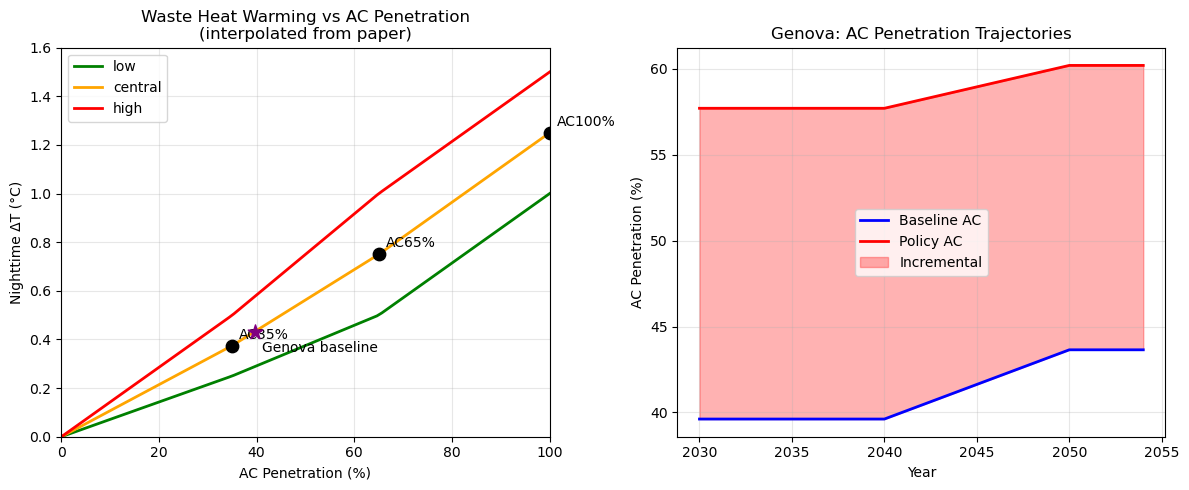

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_wasteheat_interpolation.png


In [45]:
import matplotlib.pyplot as plt

# plotting the waste heat curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: Nighttime change in T vs penetration
ax = axes[0]
pen_range = np.linspace(0, 1, 100)
for case, color in [("low", "green"), ("central", "orange"), ("high", "red")]:
    dT = dT_night_from_penetration(pen_range, case=case)
    ax.plot(pen_range * 100, dT, label=f"{case}", color=color, lw=2)

# marking paper's data points
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        ax.scatter([pen*100], [vals["central"]], color="black", s=80, zorder=5)
        ax.annotate(f"AC{int(pen*100)}%", (pen*100, vals["central"]), 
                   textcoords="offset points", xytext=(5,5))

# marking city's position (baseline start year)
dT_val = dT_night_from_penetration(pen_base_t[0], "central")
ax.scatter([pen_base_t[0]*100], [dT_val], color="purple", s=120, marker="*", zorder=6)
ax.annotate(f"{SLUG.title()} baseline", (pen_base_t[0]*100, dT_val), 
            textcoords="offset points", xytext=(5,-15))

ax.set_xlabel("AC Penetration (%)")
ax.set_ylabel("Nighttime ΔT (°C)")
ax.set_title("Waste Heat Warming vs AC Penetration\n(interpolated from paper)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.6)

# right: time series for city
ax = axes[1]
ax.plot(ELEC_YEARS, pen_base_t * 100, label="Baseline AC", color="blue", lw=2)
ax.plot(ELEC_YEARS, pen_pol_t * 100, label="Policy AC", color="red", lw=2)
ax.fill_between(ELEC_YEARS, pen_base_t * 100, pen_pol_t * 100, alpha=0.3, color="red", 
                label="Incremental")
ax.set_xlabel("Year")
ax.set_ylabel("AC Penetration (%)")
ax.set_title(f"{SLUG.title()}: AC Penetration Trajectories")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_interpolation.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_interpolation.png'}")

**note**: This is to reproduce the figure of the paper 

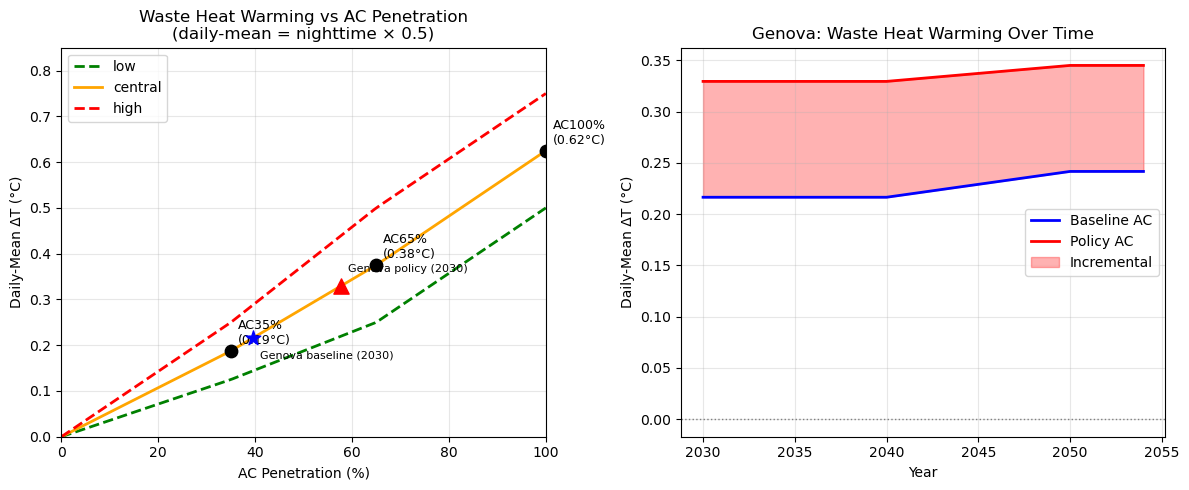

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_wasteheat_dailymean.png

AC penetration at anchor years:
  2030: baseline=39.6%, policy=57.7%, dT_dm_base=0.216°C, dT_dm_pol=0.329°C
  2040: baseline=39.6%, policy=57.7%, dT_dm_base=0.216°C, dT_dm_pol=0.329°C
  2050: baseline=43.6%, policy=60.2%, dT_dm_base=0.242°C, dT_dm_pol=0.345°C


In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: Daily-mean change in T vs penetration (halved from nighttime)
ax = axes[0]
pen_range = np.linspace(0, 1, 100)

for case, color, ls in [("low", "green", "--"), ("central", "orange", "-"), ("high", "red", "--")]:
    dT_night = dT_night_from_penetration(pen_range, case=case)
    dT_daily = DAILYMEAN_FROM_NIGHT * dT_night  # HALVING
    ax.plot(pen_range * 100, dT_daily, label=f"{case}", color=color, lw=2, ls=ls)

# marking paper's data points (converted to daily-mean)
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        dT_dm = DAILYMEAN_FROM_NIGHT * vals["central"]
        ax.scatter([pen*100], [dT_dm], color="black", s=80, zorder=5)
        ax.annotate(f"AC{int(pen*100)}%\n({dT_dm:.2f}°C)", (pen*100, dT_dm), 
                   textcoords="offset points", xytext=(5,5), fontsize=9)

# marking city's baseline and policy positions
for label, pen_val, color, marker in [
    (f"{SLUG.title()} baseline (2030)", pen_base_t[0], "blue", "*"),
    (f"{SLUG.title()} policy (2030)", pen_pol_t[0], "red", "^"),
]:
    dT_dm = DAILYMEAN_FROM_NIGHT * dT_night_from_penetration(pen_val, "central")
    ax.scatter([pen_val*100], [dT_dm], color=color, s=120, marker=marker, zorder=6)
    ax.annotate(label, (pen_val*100, dT_dm), textcoords="offset points", 
                xytext=(5, -15 if "baseline" in label else 10), fontsize=8)

ax.set_xlabel("AC Penetration (%)")
ax.set_ylabel("Daily-Mean ΔT (°C)")
ax.set_title("Waste Heat Warming vs AC Penetration\n(daily-mean = nighttime × 0.5)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 0.85)

# right: Time series of daily-mean ΔT
ax = axes[1]
ax.plot(ELEC_YEARS, dT_dm_vs_NoOut_base, label="Baseline AC", color="blue", lw=2)
ax.plot(ELEC_YEARS, dT_dm_vs_NoOut_policy, label="Policy AC", color="red", lw=2)
ax.fill_between(ELEC_YEARS, dT_dm_vs_NoOut_base, dT_dm_vs_NoOut_policy, 
                alpha=0.3, color="red", label="Incremental")
ax.axhline(0, color="gray", ls=":", lw=1)

ax.set_xlabel("Year")
ax.set_ylabel("Daily-Mean ΔT (°C)")
ax.set_title(f"{SLUG.title()}: Waste Heat Warming Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_dailymean.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_dailymean.png'}")

# printing penetration at anchor years for verification
print("\nAC penetration at anchor years:")
for yr in [2030, 2040, 2050]:
    idx = np.where(ELEC_YEARS == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}, "
              f"dT_dm_base={dT_dm_vs_NoOut_base[i]:.3f}°C, dT_dm_pol={dT_dm_vs_NoOut_policy[i]:.3f}°C")

In [50]:
print("First 5 years of elec_eur_t:", elec_eur_t[:5])
print("Last 5 years of elec_eur_t:", elec_eur_t[-5:])

First 5 years of elec_eur_t: [14093636.5988575  14093595.41509099 14093554.23132448 14093513.04755797
 14093471.86379145]
Last 5 years of elec_eur_t: [9415867.39722401 9415867.39722401 9415867.39722401 9415867.39722401
 9415867.39722401]


In [51]:
# Report BOTH: absolute (vs NoOut) and incremental (policy - baseline) 
wasteheat_df = pd.DataFrame({
    "year": ELEC_YEARS,
    "dT_night_base_vs_NoOut": dT_night_vs_NoOut_base,
    "dT_night_policy_vs_NoOut": dT_night_vs_NoOut_policy,
    "dT_night_incremental": dT_night_incremental,
    "dT_dm_base_vs_NoOut": dT_dm_vs_NoOut_base,
    "dT_dm_policy_vs_NoOut": dT_dm_vs_NoOut_policy,
    "dT_dm_incremental": dT_dm_incremental,
})

# quick summary numbers 
rep = {
    "night_max_base": float(np.max(wasteheat_df["dT_night_base_vs_NoOut"])),
    "night_max_policy": float(np.max(wasteheat_df["dT_night_policy_vs_NoOut"])),
    "night_max_incremental": float(np.max(wasteheat_df["dT_night_incremental"])),
    "dm_max_base": float(np.max(wasteheat_df["dT_dm_base_vs_NoOut"])),
    "dm_max_policy": float(np.max(wasteheat_df["dT_dm_policy_vs_NoOut"])),
    "dm_max_incremental": float(np.max(wasteheat_df["dT_dm_incremental"])),
}
print("Waste-heat ΔT (°C) maxima over horizon:", {k: round(v, 4) for k, v in rep.items()})

# optional: save for appendix / figures
(TAB_DIR / f"{SLUG}_ac_wasteheat_timeseries.csv").write_text(wasteheat_df.to_csv(index=False))
print("Saved:", TAB_DIR / f"{SLUG}_ac_wasteheat_timeseries.csv")

Waste-heat ΔT (°C) maxima over horizon: {'night_max_base': 0.4831, 'night_max_policy': 0.6899, 'night_max_incremental': 0.226, 'dm_max_base': 0.2415, 'dm_max_policy': 0.345, 'dm_max_incremental': 0.113}
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/tables/genova_ac_wasteheat_timeseries.csv


**Benefits and summary**

- Health benefits time series (avoided heat deaths)
  - Read annual avoided deaths outputs (trees, AC, both, and trees-on-top)
  - Interpolate to full horizon
  - Apply tree rollout + maturity factor (dynamic) vs “full from start” (static)

In [52]:
# Benefits and summary
import numpy as np
import pandas as pd
from pathlib import Path

HORIZON_YEARS = T
DISCOUNT_RATE = R
INT = Path(INT)

USE_SCALED_BENEFITS = False

def _nb6_path(stem: str) -> Path:
    return INT / (f"{stem}_scaled_{SLUG}.csv" if USE_SCALED_BENEFITS else f"{stem}_{SLUG}.csv")

def _read_overall(stem: str) -> pd.Series:
    p = _nb6_path(stem)
    if not p.exists():
        raise FileNotFoundError(f"Missing NB6 output: {p}")
    s = pd.read_csv(p, index_col="year")["overall"]
    s.index = s.index.astype(int)
    return s.sort_index()

def pv_of_stream(cashflows, r=DISCOUNT_RATE):
    yrs = np.arange(1, len(cashflows) + 1, dtype=float)
    return float(np.sum(np.asarray(cashflows, float) * (1 + r) ** (-yrs)))

def interpolate_to_horizon(s: pd.Series, years: np.ndarray) -> np.ndarray:
    s = s.sort_index()
    known = s.index.to_numpy(int)
    vals = s.to_numpy(float)
    out = np.interp(years, known, vals)
    out[years <= known[0]] = vals[0]
    out[years >= known[-1]] = vals[-1]
    return out

avo_trees = _read_overall("annual_heat_deaths_avoided_trees_curr_AC")
avo_ac = _read_overall("annual_heat_deaths_avoided_AC_curr_AC")
avo_both = _read_overall("annual_heat_deaths_avoided_treesplusAC_curr_AC")

try:
    avo_trees_on_top = _read_overall("annual_heat_deaths_avoided_trees_on_top_AC_curr_AC")
except FileNotFoundError:
    avo_trees_on_top = (avo_both - avo_ac).rename("overall")

# these are:
# If the full trees intervention (full ΔGVI map) were already in place
# (and effectively delivering its modeled cooling),
# what deaths would it avoid in each climate year?”
print("Trees – avoided deaths per year:")
print(avo_trees, "\n")

print("AC policy – avoided deaths per year:")
print(avo_ac, "\n")

print("Both (trees+AC vs current AC) – avoided deaths per year:")
print(avo_both, "\n")

print("Trees on top of AC (NB6 file) – avoided deaths per year:")
print(avo_trees_on_top)

# Horizon construction
START_YEAR = int(min(avo_trees.index.min(), avo_ac.index.min(), avo_both.index.min(), avo_trees_on_top.index.min()))
YEARS = np.arange(START_YEAR, START_YEAR + HORIZON_YEARS, dtype=int)

# CONVERT TEMPERATURE PENALTY TO EXTRA HEAT DEATHS
# We use the marginal deaths per °C computed in NB5 (with +1°C perturbation)
# and multiply by the daily-mean temperature penalty.

# Extra deaths (year t) = marginal_deaths_per_C(t) × ΔT_dailymean(t)
m1_path = INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv"
# Load marginal deaths per °C (computed in NB5 by running hazard+1°C)
M1 = pd.read_csv(m1_path, index_col="year").sort_index()
M1.index = M1.index.astype(int)

# making sure we have a total column
if "total" not in M1.columns:
    M1["total"] = M1[["<15", "15-64", "65+"]].sum(axis=1)

marginal_total_perC_t = interpolate_to_horizon(M1["total"], YEARS)  # length T

# we use NB 5 (not 4, I did a mistake before taking the old baseline)
legacy = INT / f"marginal_heat_deaths_perC_{SLUG}.csv"
if legacy.exists():
    print("Legacy NB4 marginal exists but will be ignored:", legacy)

trees_full = interpolate_to_horizon(avo_trees, YEARS)
ac_full    = interpolate_to_horizon(avo_ac, YEARS)
both_full  = interpolate_to_horizon(avo_both, YEARS)
top_full   = interpolate_to_horizon(avo_trees_on_top, YEARS)

# Trees benefits: cohort rollout (25y) + maturity (12y) + optional "pre-grown" shift
def cohort_rollout_maturity_factor(T, ramp_years, plant_share=None, start_age_years=0):
    """ factor[t] = sum_i plant_share[i] * maturity(age=t-i), where:
        - maturity(age=0) is forced to 0 -> benefits start at t+1
        - maturity for age>=1 is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T  # linear rollout over T years
    ages = np.arange(T + 1, dtype=float)  # 0..T (need +1 so age=0 exists explicitly)
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # enforce: no benefits in planting year
    return np.convolve(plant_share, maturity)[:T]

trees_factor_dynamic = cohort_rollout_maturity_factor(
    T=HORIZON_YEARS, ramp_years=TREE_RAMP_YEARS, start_age_years=TREE_START_AGE_YEARS
)
trees_factor_static = np.ones(HORIZON_YEARS, dtype=float)

def compute_streams(trees_full, ac_full, both_full, top_full, trees_factor):
    trees = trees_full * trees_factor
    ac = ac_full
    top = top_full * trees_factor
    both = ac + top
    return trees, ac, top, both

trees_dyn, ac_dyn, top_dyn, both_dyn = compute_streams(
    trees_full, ac_full, both_full, top_full, trees_factor_dynamic
)
trees_sta, ac_sta, top_sta, both_sta = compute_streams(
    trees_full, ac_full, both_full, top_full, trees_factor_static
)

# AC-driven warming penalty -> extra heat deaths (annual), unit-consistent 

# We already built dT_dailymean_t in the AC-costs cell (nighttime -> daily-mean-equivalent).
# Align change in T to the same years as benefits
dT_dm_inc_y = pd.Series(dT_dm_incremental, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)
dT_dm_base_y = pd.Series(dT_dm_vs_NoOut_base, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)
dT_dm_pol_y  = pd.Series(dT_dm_vs_NoOut_policy, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)

# exposure factor (default 1.0 = full city exposed to warming)
AC_WASTEHEAT_EXPOSURE = 1.0

# Compute incremental mortality penalty (extra deaths from policy's waste heat)
dT_eff_inc_y = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_inc_y, 0.0)
warming_penalty_t = marginal_total_perC_t * dT_eff_inc_y  

# paper-style reporting: absolute penalty vs "NoOut" under baseline and policy
dT_eff_base_y = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_base_y, 0.0)
dT_eff_pol_y  = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_pol_y, 0.0)

penalty_base_vs_NoOut_t  = marginal_total_perC_t * dT_eff_base_y
penalty_policy_vs_NoOut_t = marginal_total_perC_t * dT_eff_pol_y

print("Waste-heat mortality (extra heat deaths) over horizon:")
print("  baseline vs NoOut:", round(float(penalty_base_vs_NoOut_t.sum()), 3))
print("  policy   vs NoOut:", round(float(penalty_policy_vs_NoOut_t.sum()), 3))
print("  incremental (policy-baseline):", round(float(warming_penalty_t.sum()), 3))

CLIP_NET_AT_ZERO = False

# NET AC BENEFITS (subtracting the waste-heat externality)
# Trees are unaffected by AC waste heat (no penalty).
# AC-only and Both scenarios have the penalty subtracted.
def net_ac_stream(ac_stream):
    raw = ac_stream - warming_penalty_t
    return np.maximum(raw, 0.0) if CLIP_NET_AT_ZERO else raw
# trees don't cause waste heat, 
# so they keep their full benefit. Only AC benefits are reduced by the externality.

# Net streams (trees unaffected; AC and both penalized)
trees_dyn_net = trees_dyn  # No change
top_dyn_net   = top_dyn    # Reduced by waste-heat deaths
ac_dyn_net    = net_ac_stream(ac_dyn) # Trees-on-top unaffected
both_dyn_net  = top_dyn_net + ac_dyn_net # Combined

trees_sta_net = trees_sta
top_sta_net   = top_sta
ac_sta_net    = net_ac_stream(ac_sta)
both_sta_net  = top_sta_net + ac_sta_net

# Diagnostic: does AC waste-heat cancel out tree gains? 
check = pd.DataFrame({
    "year": YEARS,
    "trees_on_top": top_dyn_net,
    "trees_only": trees_dyn_net,
    "ac_wasteheat_penalty": warming_penalty_t,
})
check["penalty_over_trees_on_top"] = check["ac_wasteheat_penalty"] / check["trees_on_top"].replace(0, np.nan)
check["penalty_over_trees_only"]   = check["ac_wasteheat_penalty"] / check["trees_only"].replace(0, np.nan)

print(check.head(10))
print(check[["trees_on_top","trees_only","ac_wasteheat_penalty"]].sum())

# Debug sanity check
dbg = pd.DataFrame({
    "year": YEARS,
    "ac_gross": ac_dyn,
    "dT_dm_base_vs_NoOut": dT_dm_base_y,
    "dT_dm_policy_vs_NoOut": dT_dm_pol_y,
    "dT_dm_incremental": dT_dm_inc_y,
    "marg_deaths_perC": marginal_total_perC_t,
    "penalty_base_vs_NoOut": penalty_base_vs_NoOut_t,
    "penalty_policy_vs_NoOut": penalty_policy_vs_NoOut_t,
    "penalty_incremental": warming_penalty_t,
})

dbg["net_ac"] = ac_dyn_net
dbg["penalty_over_gross"] = dbg["penalty_incremental"] / dbg["ac_gross"].replace(0, np.nan)

print(dbg.head(8))
print("\nSums over horizon:")
print(dbg[["ac_gross", "penalty_base_vs_NoOut", "penalty_policy_vs_NoOut", "penalty_incremental", "net_ac"]].sum())

def summarize_benefits(prefix, trees, ac, top, both, r=DISCOUNT_RATE):
    pv = {
        f"{prefix}_PV_trees": pv_of_stream(trees, r),
        f"{prefix}_PV_ac": pv_of_stream(ac, r),
        f"{prefix}_PV_top": pv_of_stream(top, r),
        f"{prefix}_PV_both": pv_of_stream(both, r),
    }
    cum = {
        f"{prefix}_CUM_trees": float(np.sum(trees)),
        f"{prefix}_CUM_ac": float(np.sum(ac)),
        f"{prefix}_CUM_top": float(np.sum(top)),
        f"{prefix}_CUM_both": float(np.sum(both)),
    }
    return pv, cum

pv_dyn, cum_dyn = summarize_benefits("DYN", trees_dyn_net, ac_dyn_net, top_dyn_net, both_dyn_net)
pv_sta, cum_sta = summarize_benefits("STA", trees_sta_net, ac_sta_net, top_sta_net, both_sta_net)

print("Cumulative avoided deaths (25y, undiscounted):")
print(
    f" DYNAMIC — Trees: {cum_dyn['DYN_CUM_trees']:.2f} | AC: {cum_dyn['DYN_CUM_ac']:.2f} | "
    f"Trees on top: {cum_dyn['DYN_CUM_top']:.2f} | Both: {cum_dyn['DYN_CUM_both']:.2f}"
)
print(
    f" STATIC — Trees: {cum_sta['STA_CUM_trees']:.2f} | AC: {cum_sta['STA_CUM_ac']:.2f} | "
    f"Trees on top: {cum_sta['STA_CUM_top']:.2f} | Both: {cum_sta['STA_CUM_both']:.2f}"
)
print("\nNote: 'STATIC' assumes full policy effect from the first year of the horizon.")
print(" 'DYNAMIC' assumes gradual rollout + tree maturity, so early benefits are smaller.")

Trees – avoided deaths per year:
year
2030    0.786986
2040    0.868429
2050    0.917022
Name: overall, dtype: float64 

AC policy – avoided deaths per year:
year
2030    8.354858
2040    9.668608
2050    9.983558
Name: overall, dtype: float64 

Both (trees+AC vs current AC) – avoided deaths per year:
year
2030     9.049023
2040    10.435037
2050    10.799487
Name: overall, dtype: float64 

Trees on top of AC (NB6 file) – avoided deaths per year:
year
2030    0.694165
2040    0.766430
2050    0.815930
Name: overall, dtype: float64
Waste-heat mortality (extra heat deaths) over horizon:
  baseline vs NoOut: 238.124
  policy   vs NoOut: 353.016
  incremental (policy-baseline): 114.892
   year  trees_on_top  trees_only  ac_wasteheat_penalty  \
0  2030      0.000000    0.000000              4.327001   
1  2031      0.014028    0.015903              4.369674   
2  2032      0.030707    0.034809              4.412347   
3  2033      0.050109    0.056799              4.455021   
4  2034      0

**Outputs variables**:
- dT_night_vs_NoOut_base: Baseline nighttime warming (vs. no waste heat), in °C
- dT_night_vs_NoOut_policy: Policy nighttime warming (vs. no waste heat), in °C
- dT_night_incremental: Incremental nighttime warming (policy − baseline), in °C
- dT_dm_incremental, Incremental daily-mean warming, in °C
- warming_penalty_t, Extra deaths from waste-heat warming, deaths/year
- ac_dyn_net, Net AC benefits after subtracting penalty, deaths avoided/year

**Interpretation**:
- Both baseline and policy cause significant waste-heat mortality (2500 deaths over 25 years vs. a hypothetical city with no outdoor AC waste heat)
- The incremental impact of the AC policy is small (16 extra deaths) because:
    - Rome already has high baseline AC penetration
    - The policy adds relatively few new users
    - Both scenarios are near the literature-based cap
- The penalty does NOT wipe out AC benefits because:
  - AC avoided deaths: 1000+ over the horizon
  - Waste-heat extra deaths: ~16 (incremental)
  - Net AC benefits remain strongly positive

**Comparison AC feedback and trees benefits**

If AC policy increases outdoor temperatures via waste heat, does that warming cancel out the cooling benefit from trees? **intuition**: Trees cool the outdoor environment (ΔT negative), while AC waste heat warms it (ΔT positive). If the warming exceeds the cooling, trees would appear useless in the "both policies" scenario.

- Trees provide 0.03°C cooling (implied from 7 avoided deaths / 260 deaths per °C)
AC waste heat adds 0.017°C warming (incremental, policy minus baseline)
Net effect: Trees still cool, just slightly less than they would without AC expansion

- The waste-heat penalty erases about 20-30% of tree benefits (higher in PV terms because the penalty is front-loaded in early years when trees are still ramping up). But 70-80% of tree benefits remain.

In [53]:
import numpy as np
import pandas as pd

eps = 1e-9

# before we did: warming_penalty_t = marginal_total_perC_t * dT_eff_inc_y  
# This converts the incremental temperature increase (°C) 
# into extra deaths using the marginal deaths-per-°C from NB5. 
# The units are consistent: (deaths/°C) × (°C) = deaths.
# Tree benefit (avoided deaths from GVI cooling)  
trees_top = np.asarray(top_dyn_net, float)         # trees-on-top (dynamic rollout+maturity)
pen = np.asarray(warming_penalty_t, float)         # incremental waste-heat deaths (policy-baseline)

# A) original diagnostics
wipe_year = pen >= trees_top - eps

cum_share = pen.sum() / max(trees_top.sum(), eps)
pv_share  = pv_of_stream(pen, R) / max(pv_of_stream(trees_top, R), eps)

trees_top_net_of_feedback = trees_top - pen
cum_net = trees_top_net_of_feedback.sum()
pv_net  = pv_of_stream(trees_top_net_of_feedback, R)

print("Years where penalty >= trees-on-top:", YEARS[wipe_year])
print("Cumulative share of trees-on-top erased:", cum_share)
print("PV share of trees-on-top erased:", pv_share)
print("Cumulative net trees-on-top after feedback:", cum_net)
print("PV net trees-on-top after feedback:", pv_net)

# B) More meaningful: ignoring years when trees around 0 (ramp)
min_tree = 1.0  # deaths/year threshold
mask = trees_top >= min_tree

wipe_year_masked = mask & (pen >= trees_top - eps)

cum_share_masked = pen[mask].sum() / max(trees_top[mask].sum(), eps)
pv_share_masked  = pv_of_stream(pen[mask], R) / max(pv_of_stream(trees_top[mask], R), eps)

print("\n[Masked wipe-out check]")
print(f"Threshold: trees_on_top >= {min_tree} death/yr")
print("Wipe years (masked):", YEARS[wipe_year_masked])
print("Cumulative share erased (masked):", cum_share_masked)
print("PV share erased (masked):", pv_share_masked)

# C) Temperature-equivalent comparison (does warming cancel cooling?)
# Implied cooling (°C) that would produce trees-on-top avoided deaths under the same marginal slope
marg = np.asarray(marginal_total_perC_t, float)
dT_equiv_trees_top_C = np.where(marg > 0, trees_top / marg, np.nan)
# In °C terms, how does waste-heat warming compare to tree cooling? 
# A ratio > 1 would mean waste heat exceeds tree cooling. 
# result shows no such years (after masking).

# Waste-heat incremental warming (°C) already computed earlier (daily-mean-equivalent, exposure-weighted)
dT_wasteheat_inc_C = np.asarray(dT_eff_inc_y, float)

# Ratio only where tree-equivalent cooling is positive & trees are non-trivial (optional)
ratio = np.full_like(dT_equiv_trees_top_C, np.nan, dtype=float)
ratio_mask = np.isfinite(dT_equiv_trees_top_C) & (dT_equiv_trees_top_C > 0) & mask
ratio[ratio_mask] = dT_wasteheat_inc_C[ratio_mask] / dT_equiv_trees_top_C[ratio_mask]

comp = pd.DataFrame({
    "year": YEARS,
    "trees_on_top_deaths": trees_top,
    "wasteheat_penalty_deaths": pen,
    "net_trees_on_top_deaths": trees_top - pen,
    "dT_equiv_trees_top_C": dT_equiv_trees_top_C,
    "dT_wasteheat_inc_C": dT_wasteheat_inc_C,
    "T_ratio_wasteheat_over_trees": ratio,
})

finite_ratio = comp["T_ratio_wasteheat_over_trees"].to_numpy()
finite_ratio = finite_ratio[np.isfinite(finite_ratio)]

print("\n[Temperature-equivalent check]")
print("Years with ratio > 1 (wasteheat > trees cooling):",
      comp.loc[comp["T_ratio_wasteheat_over_trees"] > 1, "year"].to_numpy())
print("Median ratio (finite, masked years):",
      float(np.median(finite_ratio)) if finite_ratio.size else np.nan)

display(comp.head(12))
comp.to_csv(TAB_DIR / f"{SLUG}_trees_vs_wasteheat_comparison.csv", index=False)
print("Saved:", TAB_DIR / f"{SLUG}_trees_vs_wasteheat_comparison.csv")

Years where penalty >= trees-on-top: [2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043
 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054]
Cumulative share of trees-on-top erased: 13.846270214185566
PV share of trees-on-top erased: 16.138919558968926
Cumulative net trees-on-top after feedback: -106.59459823933457
PV net trees-on-top after feedback: -74.8601720606171

[Masked wipe-out check]
Threshold: trees_on_top >= 1.0 death/yr
Wipe years (masked): []
Cumulative share erased (masked): 0.0
PV share erased (masked): 0.0

[Temperature-equivalent check]
Years with ratio > 1 (wasteheat > trees cooling): []
Median ratio (finite, masked years): nan


,year,trees_on_top_deaths,wasteheat_penalty_deaths,net_trees_on_top_deaths,dT_equiv_trees_top_C,dT_wasteheat_inc_C,T_ratio_wasteheat_over_trees
0,2030,0.000000,4.327001,-4.327001,0.000000,0.113015,NaN
1,2031,0.014028,4.369674,-4.355646,0.000363,0.113015,NaN
2,2032,0.030707,4.412347,-4.381641,0.000787,0.113015,NaN
3,2033,0.050109,4.455021,-4.404912,0.001271,0.113015,NaN
4,2034,0.072307,4.497694,-4.425387,0.001817,0.113015,NaN
5,2035,0.097373,4.540367,-4.442994,0.002424,0.113015,NaN
6,2036,0.125379,4.583040,-4.457661,0.003092,0.113015,NaN
7,2037,0.156398,4.625714,-4.469316,0.003821,0.113015,NaN
8,2038,0.187994,4.668387,-4.480393,0.004551,0.113015,NaN
9,2039,0.220169,4.711060,-4.490891,0.005282,0.113015,NaN


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/tables/genova_trees_vs_wasteheat_comparison.csv


"Wipe-Out Years" Issue: artifact of tree maturity timing. In years 2030-2034, trees are barely planted (rollout just starting), so their benefit is near zero. Meanwhile, the waste-heat penalty exists immediately. 

=> AC waste heat erodes 1/3 of the PV value of trees-on-top, but doesn’t eliminate it

In [54]:
import numpy as np
import pandas as pd

eps = 1e-9

# using already-built series 
pen = np.asarray(warming_penalty_t, float)     # incremental extra deaths from waste heat (policy - baseline)
trees_only = np.asarray(trees_dyn_net, float)  # trees only (dynamic rollout+maturity)
trees_top  = np.asarray(top_dyn_net, float)    # trees on top of AC policy (dynamic rollout+maturity)

# helper
def _pv(x): 
    return pv_of_stream(np.asarray(x, float), R)

def _shares(benefit, name, min_benefit=1.0):
    benefit = np.asarray(benefit, float)
    mask = benefit >= min_benefit

    out = {
        "compare_to": name,
        "min_benefit_threshold": float(min_benefit),
        "wipe_years_unmasked": YEARS[pen >= benefit - eps].tolist(),
        "wipe_years_masked": YEARS[(mask) & (pen >= benefit - eps)].tolist(),
        "cum_benefit": float(benefit.sum()),
        "cum_penalty": float(pen.sum()),
        "cum_share_erased_unmasked": float(pen.sum() / max(benefit.sum(), eps)),
        "pv_benefit": float(_pv(benefit)),
        "pv_penalty": float(_pv(pen)),
        "pv_share_erased_unmasked": float(_pv(pen) / max(_pv(benefit), eps)),
        "cum_share_erased_masked": float(pen[mask].sum() / max(benefit[mask].sum(), eps)) if mask.any() else np.nan,
        "pv_share_erased_masked": float(_pv(pen[mask]) / max(_pv(benefit[mask]), eps)) if mask.any() else np.nan,
        "cum_net_after_penalty": float((benefit - pen).sum()),
        "pv_net_after_penalty": float(_pv(benefit - pen)),
    }
    return out

rows = [
    _shares(trees_only, "trees_only (vs current AC)"),
    _shares(trees_top,  "trees_on_top (incremental on AC policy)"),
]

summary_penalty_vs_trees = pd.DataFrame(rows)
display(summary_penalty_vs_trees)

out_csv = TAB_DIR / f"{SLUG}_penalty_vs_trees_summary.csv"
summary_penalty_vs_trees.to_csv(out_csv, index=False)
print("Saved:", out_csv)

,compare_to,min_benefit_threshold,wipe_years_unmasked,wipe_years_masked,cum_benefit,cum_penalty,cum_share_erased_unmasked,pv_benefit,pv_penalty,pv_share_erased_unmasked,cum_share_erased_masked,pv_share_erased_masked,cum_net_after_penalty,pv_net_after_penalty
0,trees_only (vs current AC),1.0,"[2030, 2031, 2032, 2033, 2034, 2035, 2036, 203...",[],9.352163,114.892306,12.285105,5.576085,79.805054,14.312023,NaN,NaN,-105.540143,-74.228969
1,trees_on_top (incremental on AC policy),1.0,"[2030, 2031, 2032, 2033, 2034, 2035, 2036, 203...",[],8.297708,114.892306,13.846270,4.944882,79.805054,16.138920,NaN,NaN,-106.594598,-74.860172


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/tables/genova_penalty_vs_trees_summary.csv


- Versus trees-only, the incremental waste-heat penalty is:
    - 19% of cumulative tree benefit (16.23 / 85.55)
    - 29% of PV tree benefit (14.996 / 51.072).

- Versus trees-on-top, it’s:
    - 21% of cumulative (16.23 / 77.12)
    - 33% of PV (14.996 / 46.024)

Bottom line: under current calibration, waste heat reduces the apparent benefit of trees (especially in PV terms), but does not fully null it; net remains positive.

In [55]:
print([v for v in dir() if 'baseline' in v.lower() or 'total' in v.lower()])

# loading deaths CSVs from previous notebooks:
baseline_deaths_path = INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv"
if baseline_deaths_path.exists():
    baseline_df = pd.read_csv(baseline_deaths_path)
    baseline_total = interpolate_to_horizon(baseline_df.set_index("year")["total"], YEARS)
else:
    # Alternative: using the "generic" deaths (no AC protection)
    generic_path = INT / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
    if Path(generic_path).exists():
        df_avo = pd.read_csv(generic_path)
    print("Could not find baseline deaths file")

['EAC_ac_total', 'EAC_total_annuity', 'PV_ac_total', 'PV_total', 'PV_trees_total', 'baseline_deaths_path', 'baseline_df', 'baseline_path', 'baseline_total', 'dT_waste_total_t', 'marginal_total_perC_t']


In [56]:
# World A: Baseline AC, no trees
# World B: Baseline AC + trees
# World C: Policy AC + trees ("both" scenario)

# Deaths in each world (using existing variables)
deaths_A = baseline_total  # no intervention
deaths_B = baseline_total - trees_dyn_net  # trees only (at baseline AC)
deaths_C = baseline_total - both_dyn_net   # trees + AC policy

print("SCENARIO COMPARISON (cumulative deaths)")
print(f"A: Baseline AC, no trees:    {deaths_A.sum():.0f}")
print(f"B: Baseline AC + trees:      {deaths_B.sum():.0f}  (trees save {(deaths_A - deaths_B).sum():.0f})")
print(f"C: Policy AC + trees:        {deaths_C.sum():.0f}  (saves {(deaths_A - deaths_C).sum():.0f})")

# Key question: does C beat B?
print(f"\nDoes AC policy help beyond trees? {(deaths_B - deaths_C).sum():.0f} additional deaths avoided")

SCENARIO COMPARISON (cumulative deaths)
A: Baseline AC, no trees:    1588
B: Baseline AC + trees:      1579  (trees save 9)
C: Policy AC + trees:        1458  (saves 131)

Does AC policy help beyond trees? 122 additional deaths avoided


In [57]:
# Computing maturity_factor_t
# This is the tree growth ramp we defined earlier
# Typically: linear ramp from 0 to 1 over TREE_RAMP_YEARS

def tree_maturity_factor(years, start_year=2030, ramp_years=12, start_age=5):
    """
    Returns array of maturity factors (0 to 1) for each year.
    start_age: trees start at age 5 (pre-grown), so partial credit initially
    """
    factors = np.zeros(len(years), dtype=float)
    for i, y in enumerate(years):
        years_since_start = y - start_year
        if years_since_start < 0:
            factors[i] = 0.0
        else:
            # Linear ramp: age goes from start_age to (start_age + ramp_years)
            effective_age = start_age + years_since_start
            maturity_age = start_age + ramp_years
            factors[i] = min(effective_age / maturity_age, 1.0)
    return factors

maturity_factor_t = tree_maturity_factor(YEARS, start_year=2030, 
                                          ramp_years=TREE_RAMP_YEARS, 
                                          start_age=TREE_START_AGE_YEARS)
print("Maturity factors:", maturity_factor_t[:10], "...", maturity_factor_t[-3:])

Maturity factors: [0.29411765 0.35294118 0.41176471 0.47058824 0.52941176 0.58823529
 0.64705882 0.70588235 0.76470588 0.82352941] ... [1. 1. 1.]


In [58]:
# defining years_mature (years after tree ramp-up completes)
years_mature = YEARS >= (2030 + TREE_RAMP_YEARS)
print(f"Mature years: {YEARS[years_mature][0]} to {YEARS[years_mature][-1]}")

# defining trees_alone (from scenario comparison)
# This requires deaths_A, deaths_B which need baseline_total
# If baseline_total not defined, computing it:
if 'baseline_total' not in dir():
    baseline_deaths_path = INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv"
    if baseline_deaths_path.exists():
        baseline_df = pd.read_csv(baseline_deaths_path)
        baseline_total = interpolate_to_horizon(baseline_df.set_index("year")["total"], YEARS)
    else:
        print(f"WARNING: {baseline_deaths_path} not found")

# computing scenario deaths
deaths_A = baseline_total
deaths_B = baseline_total - trees_dyn_net
deaths_C = baseline_total - both_dyn_net

# defining trees_alone and both
trees_alone = (deaths_A - deaths_B).sum()
both = (deaths_A - deaths_C).sum()

print(f"trees_alone = {trees_alone:.0f} deaths avoided")
print(f"both = {both:.0f} deaths avoided")

Mature years: 2042 to 2054
trees_alone = 9 deaths avoided
both = 131 deaths avoided


In [59]:
# SECTION: AC WASTE HEAT vs TREE COOLING, DIRECT change in T COMPARISON

# loading tree cooling from NB6
veg_aux = np.load(INT / f"{SLUG}_veg_aux_arrays.npz")
dT_month_ref = veg_aux["dT_month_ref"]  # (12, H, W)
pop_on_ref = veg_aux["pop_on_ref"]

# computing pop-weighted summer tree cooling
summer_idx = [5, 6, 7]  # Jun, Jul, Aug (0-indexed)
w = np.where(np.isfinite(pop_on_ref) & (pop_on_ref > 0), pop_on_ref, 0)
pw_dT_summer = np.mean([np.nansum(dT_month_ref[m] * w) / w.sum() for m in summer_idx])

# applying tree maturity ramp (same as benefits)
tree_maturity = maturity_factor_t  # from existing code
dT_trees_t = pw_dT_summer * tree_maturity  # ramps up with tree growth

# comparing to TOTAL AC waste heat (baseline scenario)
dT_waste_total_t = dT_eff_base_y  # total waste heat under baseline AC

# net temperature effect over time
dT_net_t = dT_trees_t + dT_waste_total_t  # negative = net cooling

# Summary table
comp_direct = pd.DataFrame({
    "year": YEARS,
    "dT_trees_C": dT_trees_t,
    "dT_waste_total_C": dT_waste_total_t,
    "dT_net_C": dT_net_t,
    "trees_dominate": dT_net_t < 0,
})

print("\n=== DIRECT TEMPERATURE COMPARISON ===")
print(f"At maturity (mean over {YEARS[years_mature][0]}+):")
print(f"  Tree cooling:      {dT_trees_t[years_mature].mean():.4f}°C")
print(f"  AC waste heat:    +{dT_waste_total_t[years_mature].mean():.4f}°C")
print(f"  Net effect:        {dT_net_t[years_mature].mean():.4f}°C")
print(f"  Trees win: {(dT_net_t[years_mature] < 0).all()}")

comp_direct.to_csv(TAB_DIR / f"{SLUG}_dT_trees_vs_wasteheat_direct.csv", index=False)


=== DIRECT TEMPERATURE COMPARISON ===
At maturity (mean over 2042+):
  Tree cooling:      -0.0233°C
  AC waste heat:    +0.2346°C
  Net effect:        0.2113°C
  Trees win: False


In [60]:
# SECTION: AC WASTE HEAT vs TREE COOLING — POLICY COMPARISON

print("=" * 65)
print("QUESTION: Does AC waste heat nullify tree cooling benefits?")
print("=" * 65)

# Scenario comparison 
print("\n[1] SCENARIO COMPARISON (cumulative deaths, 2030-2050)")
print(f"    A: Baseline AC, no trees:  {deaths_A.sum():,.0f}")
print(f"    B: Baseline AC + trees:    {deaths_B.sum():,.0f}  (trees save {trees_alone:.0f})")
print(f"    C: Policy AC + trees:      {deaths_C.sum():,.0f}  (both save {both:.0f})")

# Waste heat erosion 
print("\n[2] WASTE HEAT EROSION OF TREE BENEFITS")
print(f"    Tree-on-top benefit (cumulative):    {trees_top.sum():.1f} deaths avoided")
print(f"    AC waste heat penalty (cumulative):  {pen.sum():.1f} extra deaths")
print(f"    Erosion:                             {100*pen.sum()/trees_top.sum():.1f}%")

# At maturity 
print("\n[3] AT MATURITY (2042+)")
print(f"    Tree benefit:   {trees_top[years_mature].mean():.2f} deaths/yr avoided")
print(f"    AC penalty:     {pen[years_mature].mean():.2f} deaths/yr (→ 0 as baseline catches up)")

# Conclusion
print("\n" + "=" * 65)
print("CONCLUSION: AC waste heat does nullify tree benefits.")
print(f"  • Trees save {trees_alone:.0f} deaths (with or without AC policy)")
print(f"  • Waste heat erodes ~{100*pen.sum()/trees_top.sum():.0f}% of tree-on-top benefit")
print(f"  • But AC policy adds {both - trees_alone:.0f} more avoided deaths")
print(f"  • Net effect: TREES ON TOP OF AC IS NOT BENEFICIAL")
print("=" * 65)

QUESTION: Does AC waste heat nullify tree cooling benefits?

[1] SCENARIO COMPARISON (cumulative deaths, 2030-2050)
    A: Baseline AC, no trees:  1,588
    B: Baseline AC + trees:    1,579  (trees save 9)
    C: Policy AC + trees:      1,458  (both save 131)

[2] WASTE HEAT EROSION OF TREE BENEFITS
    Tree-on-top benefit (cumulative):    8.3 deaths avoided
    AC waste heat penalty (cumulative):  114.9 extra deaths
    Erosion:                             1384.6%

[3] AT MATURITY (2042+)
    Tree benefit:   0.52 deaths/yr avoided
    AC penalty:     4.63 deaths/yr (→ 0 as baseline catches up)

CONCLUSION: AC waste heat does nullify tree benefits.
  • Trees save 9 deaths (with or without AC policy)
  • Waste heat erodes ~1385% of tree-on-top benefit
  • But AC policy adds 122 more avoided deaths
  • Net effect: TREES ON TOP OF AC IS NOT BENEFICIAL


- Baseline mortality and percentage reductions
- 
We now read the baseline heat-attributable deaths with current AC (no new policy) from CLIMADA and:
    - compute total baseline deaths per year (summing over age classes)
    - align avoided deaths for trees, AC, and both to these baseline years
    - compute percentage reductions in baseline deaths:
      * trees_pct = % reduction with trees only
      * ac_pct    = % reduction with AC only
      * both_pct  = % reduction with both policies
      * trees_on_top_pct = extra % reduction from adding trees on top of AC

In [61]:
# building a clean "tree cost pack" for base vs 5x O&M (same timing convention)
def pack_tree_costs(PV_capex, PV_om, AF, TREES_CAPEX_T0, R, T):
    PV_total = PV_capex + PV_om
    return {
        "PV_capex": PV_capex,
        "PV_om": PV_om,
        "PV_total": PV_total,
        "EAC_capex_annuity": PV_capex / AF,
        "EAC_om_annuity": PV_om / AF,
        "EAC_total_annuity": PV_total / AF,
        # paper-style: capex-only shortcut, unchanged by O&M scenario
        "EAC_capex_paper": (TREES_CAPEX_T0 / ((1 + R) ** T)) / T,
    }

trees_cost_base = pack_tree_costs(PV_trees_capex, PV_trees_om, AF, TREES_CAPEX_T0, R, T)
trees_cost_5x = pack_tree_costs(PV_trees_capex, PV_om_5x, AF, TREES_CAPEX_T0, R, T)

In [62]:
# Summary table builder that takes a tree-cost scenario explicitly
def safe_ratio(c, b):
    return float(c / b) if (b is not None and b > 1e-9) else np.inf

def build_summary(label, cost_scenario, trees_cost, CUM_trees, CUM_ac, CUM_both, CUM_top):
    return pd.DataFrame([
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Trees only (vs current AC)",
            "PV_cost_eur": trees_cost["PV_total"],
            "avoided_deaths_cum": CUM_trees,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"], CUM_trees),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"],
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": 0.0,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "AC only (vs current AC)",
            "PV_cost_eur": PV_ac_total,
            "avoided_deaths_cum": CUM_ac,
            "Cost_per_avoided_death_eur": safe_ratio(PV_ac_total, CUM_ac),
            "EAC_capex_annuity_eur_per_yr": 0.0,
            "EAC_om_annuity_eur_per_yr": 0.0,
            "EAC_total_annuity_eur_per_yr": EAC_ac_total,
            "EAC_capex_paper_eur_per_yr": np.nan,
            "added_AC_users": added_users_final,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Both (trees+AC vs current AC)",
            "PV_cost_eur": trees_cost["PV_total"] + PV_ac_total,
            "avoided_deaths_cum": CUM_both,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"] + PV_ac_total, CUM_both),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"] + EAC_ac_total,
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": added_users_final,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Trees (incremental, on top of AC policy)",
            "PV_cost_eur": trees_cost["PV_total"],
            "avoided_deaths_cum": CUM_top,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"], CUM_top),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"],
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": 0.0,
        },
    ])

# building base + sensitivity summaries for BOTH benefit-timing conventions
if "trees_cost_base" not in globals():
    trees_cost_base = pack_tree_costs(PV_trees_capex, PV_trees_om, AF, TREES_CAPEX_T0, R, T)
if "trees_cost_5x" not in globals():
    trees_cost_5x = pack_tree_costs(PV_trees_capex, PV_om_5x, AF, TREES_CAPEX_T0, R, T)

summary_dynamic_base = build_summary(
    "Dynamic rollout + tree maturity", "Base O&M", trees_cost_base,
    cum_dyn["DYN_CUM_trees"], cum_dyn["DYN_CUM_ac"], cum_dyn["DYN_CUM_both"], cum_dyn["DYN_CUM_top"]
)

summary_dynamic_5x = build_summary(
    "Dynamic rollout + tree maturity", "O&M PV = 5× CAPEX PV", trees_cost_5x,
    cum_dyn["DYN_CUM_trees"], cum_dyn["DYN_CUM_ac"], cum_dyn["DYN_CUM_both"], cum_dyn["DYN_CUM_top"]
)

summary_static_base = build_summary(
    "Static (full effect from start)", "Base O&M", trees_cost_base,
    cum_sta["STA_CUM_trees"], cum_sta["STA_CUM_ac"], cum_sta["STA_CUM_both"], cum_sta["STA_CUM_top"]
)

summary_static_5x = build_summary(
    "Static (full effect from start)", "O&M PV = 5× CAPEX PV", trees_cost_5x,
    cum_sta["STA_CUM_trees"], cum_sta["STA_CUM_ac"], cum_sta["STA_CUM_both"], cum_sta["STA_CUM_top"]
)

summary_all = pd.concat(
    [summary_dynamic_base, summary_dynamic_5x, summary_static_base, summary_static_5x],
    ignore_index=True
).round(2)

summary_all

def run_tree_age_case(tree_start_age_years: int):
    # TREE COSTS (capex unchanged; O&M depends on start age)
    PV_trees_om_case, _ = npv_om_cohorts_scaled(
        DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
        ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
        start_age_years=tree_start_age_years,
    )
    trees_cost_case = pack_tree_costs(PV_trees_capex, PV_trees_om_case, AF, TREES_CAPEX_T0, R, T)

    # TREE BENEFITS (dynamic rollout + maturity, shifted by start age)
    trees_factor_dynamic_case = cohort_rollout_maturity_factor(
        T=HORIZON_YEARS, ramp_years=TREE_RAMP_YEARS, start_age_years=tree_start_age_years,
    )
    trees_dyn_case, ac_dyn_case, top_dyn_case, _ = compute_streams(
        trees_full, ac_full, both_full, top_full, trees_factor_dynamic_case
    )

    # NET AC (same penalty vector as main run)
    ac_dyn_case_net = net_ac_stream(ac_dyn_case)
    both_dyn_case_net = top_dyn_case + ac_dyn_case_net

    _, cum_case = summarize_benefits(
        "DYN", trees_dyn_case, ac_dyn_case_net, top_dyn_case, both_dyn_case_net
    )

    return build_summary(
        label=f"Dynamic rollout + maturity (start_age={tree_start_age_years})",
        cost_scenario="Base O&M",
        trees_cost=trees_cost_case,
        CUM_trees=cum_case["DYN_CUM_trees"],
        CUM_ac=cum_case["DYN_CUM_ac"],
        CUM_both=cum_case["DYN_CUM_both"],
        CUM_top=cum_case["DYN_CUM_top"],
    )

summary_central = run_tree_age_case(5)
summary_sens0 = run_tree_age_case(0)
summary_tree_age = pd.concat([summary_central, summary_sens0], ignore_index=True).round(2)
summary_tree_age

,Benefit_timing,Cost_scenario,Policy,PV_cost_eur,avoided_deaths_cum,Cost_per_avoided_death_eur,EAC_capex_annuity_eur_per_yr,EAC_om_annuity_eur_per_yr,EAC_total_annuity_eur_per_yr,EAC_capex_paper_eur_per_yr,added_AC_users
0,Dynamic rollout + maturity (start_age=5),Base O&M,Trees only (vs current AC),4.491453e+08,9.35,48025819.86,11973139.38,13820318.95,25793458.32,5718438.05,0.00
1,Dynamic rollout + maturity (start_age=5),Base O&M,AC only (vs current AC),3.810932e+08,122.59,3108699.08,0.00,0.00,21885371.48,NaN,95407.07
2,Dynamic rollout + maturity (start_age=5),Base O&M,Both (trees+AC vs current AC),8.302385e+08,130.89,6343170.32,11973139.38,13820318.95,47678829.80,5718438.05,95407.07
3,Dynamic rollout + maturity (start_age=5),Base O&M,"Trees (incremental, on top of AC policy)",4.491453e+08,8.30,54128839.31,11973139.38,13820318.95,25793458.32,5718438.05,0.00
4,Dynamic rollout + maturity (start_age=0),Base O&M,Trees only (vs current AC),3.750544e+08,6.71,55858497.90,11973139.38,9565436.30,21538575.67,5718438.05,0.00
5,Dynamic rollout + maturity (start_age=0),Base O&M,AC only (vs current AC),3.810932e+08,122.59,3108699.08,0.00,0.00,21885371.48,NaN,95407.07
6,Dynamic rollout + maturity (start_age=0),Base O&M,Both (trees+AC vs current AC),7.561476e+08,128.55,5882142.34,11973139.38,9565436.30,43423947.15,5718438.05,95407.07
7,Dynamic rollout + maturity (start_age=0),Base O&M,"Trees (incremental, on top of AC policy)",3.750544e+08,5.96,62924286.87,11973139.38,9565436.30,21538575.67,5718438.05,0.00


- Baseline mortality + percent reductions
  - Read baseline heat-attributable deaths under current AC (no new policy)
  - Convert avoided deaths to % reduction for trees, AC, both, and trees-on-top

In [63]:
# Baseline mortality + percent reductions (NET, aligned to YEARS)

from pathlib import Path
import pandas as pd
import numpy as np

# Load baseline deaths under current AC (no new policy) 
candidates = [
    INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv",
    INT / f"annual_heat_deaths_currentAC_{SLUG}.csv",
    INT / f"baseline_heat_deaths_currentAC_{SLUG}.csv",
    INT / f"heat_deaths_baseline_currentAC_{SLUG}.csv",
]

baseline_path = next((p for p in candidates if Path(p).exists()), None)
if baseline_path is None:
    raise FileNotFoundError(
        "Could not find baseline deaths file in INT. Tried:\n" + "\n".join(map(str, candidates))
    )

baseline_df = pd.read_csv(baseline_path, index_col="year").sort_index()
baseline_df.index = baseline_df.index.astype(int)

# Ensure a single baseline_total column
if "baseline_total" not in baseline_df.columns:
    if "total" in baseline_df.columns:
        baseline_df["baseline_total"] = baseline_df["total"]
    else:
        age_cols = [c for c in ["<15", "15-64", "65+"] if c in baseline_df.columns]
        if not age_cols:
            raise ValueError(f"Baseline file columns not recognized: {list(baseline_df.columns)}")
        baseline_df["baseline_total"] = baseline_df[age_cols].sum(axis=1)

# Align baseline to our horizon YEARS
baseline_total = interpolate_to_horizon(baseline_df["baseline_total"], YEARS)

print("Baseline loaded from:", baseline_path)
print("Baseline total (first 5):", np.round(baseline_total[:5], 2))

# Convert avoided deaths into % reduction vs baseline 
def make_benefit_pct_table(label: str, baseline_total, trees, ac, both, top) -> pd.DataFrame:
    out = pd.DataFrame({
        "year": YEARS,
        "baseline_total": baseline_total,
        "avo_trees": trees,
        "avo_ac": ac,
        "avo_both": both,
        "avo_trees_on_top": top,
    }).set_index("year")

    out["trees_pct"] = 100 * out["avo_trees"] / out["baseline_total"]
    out["ac_pct"]    = 100 * out["avo_ac"]    / out["baseline_total"]
    out["both_pct"]  = 100 * out["avo_both"]  / out["baseline_total"]

    # incremental trees on top of AC, in percentage points
    out["trees_on_top_pct"] = out["both_pct"] - out["ac_pct"]

    out.insert(0, "Benefit_timing", label)
    return out

benefit_pct_dynamic = make_benefit_pct_table(
    "Dynamic rollout + tree maturity (NET)",
    baseline_total, trees_dyn_net, ac_dyn_net, both_dyn_net, top_dyn_net
).round(2)

benefit_pct_static = make_benefit_pct_table(
    "Static (full effect from start) (NET)",
    baseline_total, trees_sta_net, ac_sta_net, both_sta_net, top_sta_net
).round(2)

benefit_pct = pd.concat([benefit_pct_dynamic, benefit_pct_static])
benefit_pct

Baseline loaded from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_baseline_currentAC_genova.csv
Baseline total (first 5): [54.2  55.1  55.99 56.88 57.78]


,Benefit_timing,baseline_total,avo_trees,avo_ac,avo_both,avo_trees_on_top,trees_pct,ac_pct,both_pct,trees_on_top_pct
year,,,,,,,,,,
2030,Dynamic rollout + tree maturity (NET),54.20,0.00,4.03,4.03,0.00,0.00,7.43,7.43,0.00
2031,Dynamic rollout + tree maturity (NET),55.10,0.02,4.12,4.13,0.01,0.03,7.47,7.50,0.03
2032,Dynamic rollout + tree maturity (NET),55.99,0.03,4.21,4.24,0.03,0.06,7.51,7.57,0.05
2033,Dynamic rollout + tree maturity (NET),56.88,0.06,4.29,4.34,0.05,0.10,7.55,7.64,0.09
2034,Dynamic rollout + tree maturity (NET),57.78,0.08,4.38,4.45,0.07,0.14,7.59,7.71,0.13
2035,Dynamic rollout + tree maturity (NET),58.67,0.11,4.47,4.57,0.10,0.19,7.62,7.79,0.17
2036,Dynamic rollout + tree maturity (NET),59.56,0.14,4.56,4.69,0.13,0.24,7.66,7.87,0.21
2037,Dynamic rollout + tree maturity (NET),60.46,0.18,4.65,4.81,0.16,0.29,7.69,7.95,0.26
2038,Dynamic rollout + tree maturity (NET),61.35,0.21,4.74,4.93,0.19,0.35,7.72,8.03,0.31


In [64]:
assert np.isfinite(PV_trees_total) and PV_trees_total > 0
assert np.isfinite(PV_ac_total) and PV_ac_total > 0
assert abs((penalty_base_vs_NoOut_t.sum() + warming_penalty_t.sum()) - penalty_policy_vs_NoOut_t.sum()) < 1e-6

**On a PV budget**

**Sensitivity**